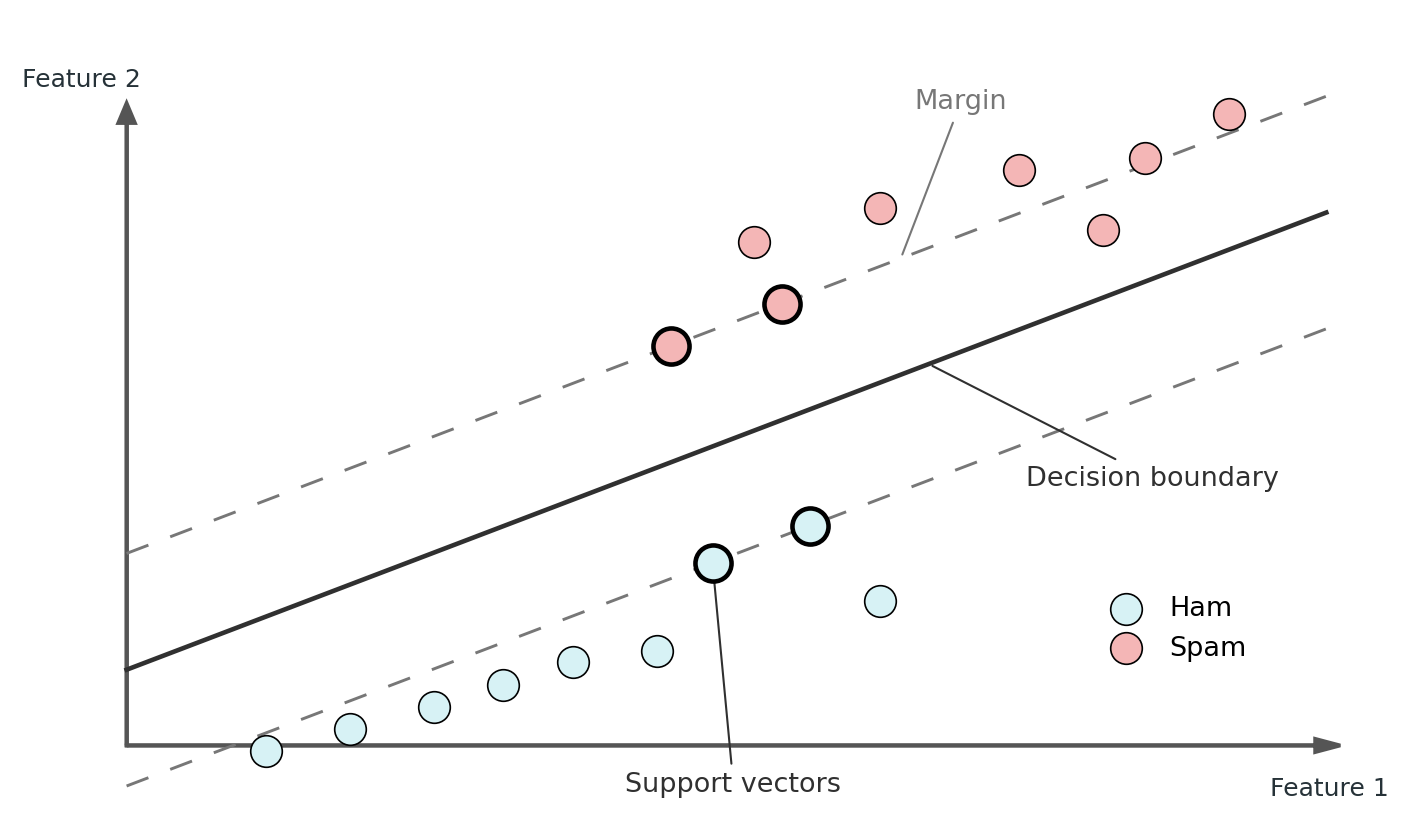

Saved to: D:\Project\Leeds\Msc Project\figure\figure_2_2_svm_margin.png


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Save path
project_dir = Path(r"D:\Project\Leeds\Msc Project")
figure_dir = project_dir / "figure"
figure_dir.mkdir(parents=True, exist_ok=True)

output_path = figure_dir / "figure_2_2_svm_margin.png"

# Figure setup
plt.figure(figsize=(12, 7), dpi=150)
ax = plt.gca()
ax.set_xlim(0, 10)
ax.set_ylim(0, 7.3)
ax.axis("off")

# Axes with arrows
ax.arrow(0.8, 0.7, 8.7, 0, head_width=0.12, head_length=0.18,
         fc="#555555", ec="#555555", linewidth=1.8, length_includes_head=True)
ax.arrow(0.8, 0.7, 0, 5.8, head_width=0.12, head_length=0.18,
         fc="#555555", ec="#555555", linewidth=1.8, length_includes_head=True)

ax.text(9.0, 0.25, "Feature 1", fontsize=12, color="#263238")
ax.text(0.05, 6.65, "Feature 2", fontsize=12, color="#263238")

# Decision boundary and margins
x = np.linspace(0.8, 9.4, 300)
slope = 0.48
intercept = 1.00
margin_width = 1.05

def boundary_y(values):
    return slope * values + intercept

def upper_margin_y(values):
    return boundary_y(values) + margin_width

def lower_margin_y(values):
    return boundary_y(values) - margin_width

boundary = boundary_y(x)
margin_upper = upper_margin_y(x)
margin_lower = lower_margin_y(x)

ax.plot(x, boundary, color="#303030", linewidth=2.2, zorder=1)
ax.plot(x, margin_upper, color="#777777", linestyle=(0, (8, 8)), linewidth=1.4, zorder=1)
ax.plot(x, margin_lower, color="#777777", linestyle=(0, (8, 8)), linewidth=1.4, zorder=1)

# Sample points
ham = np.array([
    [1.8, 0.65], [2.4, 0.85], [3.0, 1.05], [3.5, 1.25],
    [4.0, 1.45], [4.6, 1.55], [6.2, 2.00]
])

spam = np.array([
    [5.3, 5.25], [6.2, 5.55], [7.2, 5.90], [8.1, 6.00],
    [8.7, 6.40], [7.8, 5.35]
])

# Support vectors are placed exactly on the two margin lines.
support_ham_x = np.array([5.0, 5.7])
support_spam_x = np.array([4.7, 5.5])
support_ham = np.column_stack((support_ham_x, lower_margin_y(support_ham_x)))
support_spam = np.column_stack((support_spam_x, upper_margin_y(support_spam_x)))

# Plot normal points
ax.scatter(ham[:, 0], ham[:, 1], s=230, c="#d7f2f5",
           edgecolors="black", linewidths=0.8, label="Ham", zorder=3)
ax.scatter(spam[:, 0], spam[:, 1], s=230, c="#f4b6b6",
           edgecolors="black", linewidths=0.8, label="Spam", zorder=3)

# Plot support vectors with thicker outlines
ax.scatter(support_ham[:, 0], support_ham[:, 1], s=300, c="#d7f2f5",
           edgecolors="black", linewidths=2.2, zorder=4)
ax.scatter(support_spam[:, 0], support_spam[:, 1], s=300, c="#f4b6b6",
           edgecolors="black", linewidths=2.2, zorder=4)

# Annotations
ax.annotate("Margin",
            xy=(6.35, upper_margin_y(6.35)), xytext=(6.45, 6.45),
            fontsize=13, color="#777777",
            arrowprops=dict(arrowstyle="-", color="#777777", linewidth=1.0))

ax.annotate("Decision boundary",
            xy=(6.55, boundary_y(6.55)), xytext=(7.25, 3.05),
            fontsize=13, color="#303030",
            arrowprops=dict(arrowstyle="-", color="#303030", linewidth=1.0))

# Support vectors are the outlined samples on the margin lines.
ax.annotate("Support vectors",
            xy=(support_ham[0, 0], support_ham[0, 1]), xytext=(5.15, 0.28),
            fontsize=13, color="#303030", ha="center",
            arrowprops=dict(arrowstyle="-", color="#303030", linewidth=1.0))

# Legend
legend = ax.legend(loc="lower right", bbox_to_anchor=(0.90, 0.17),
                   frameon=False, fontsize=13, handletextpad=0.6)
for handle in legend.legend_handles:
    handle.set_sizes([230])

# Save and display
plt.savefig(output_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Saved to: {output_path}")

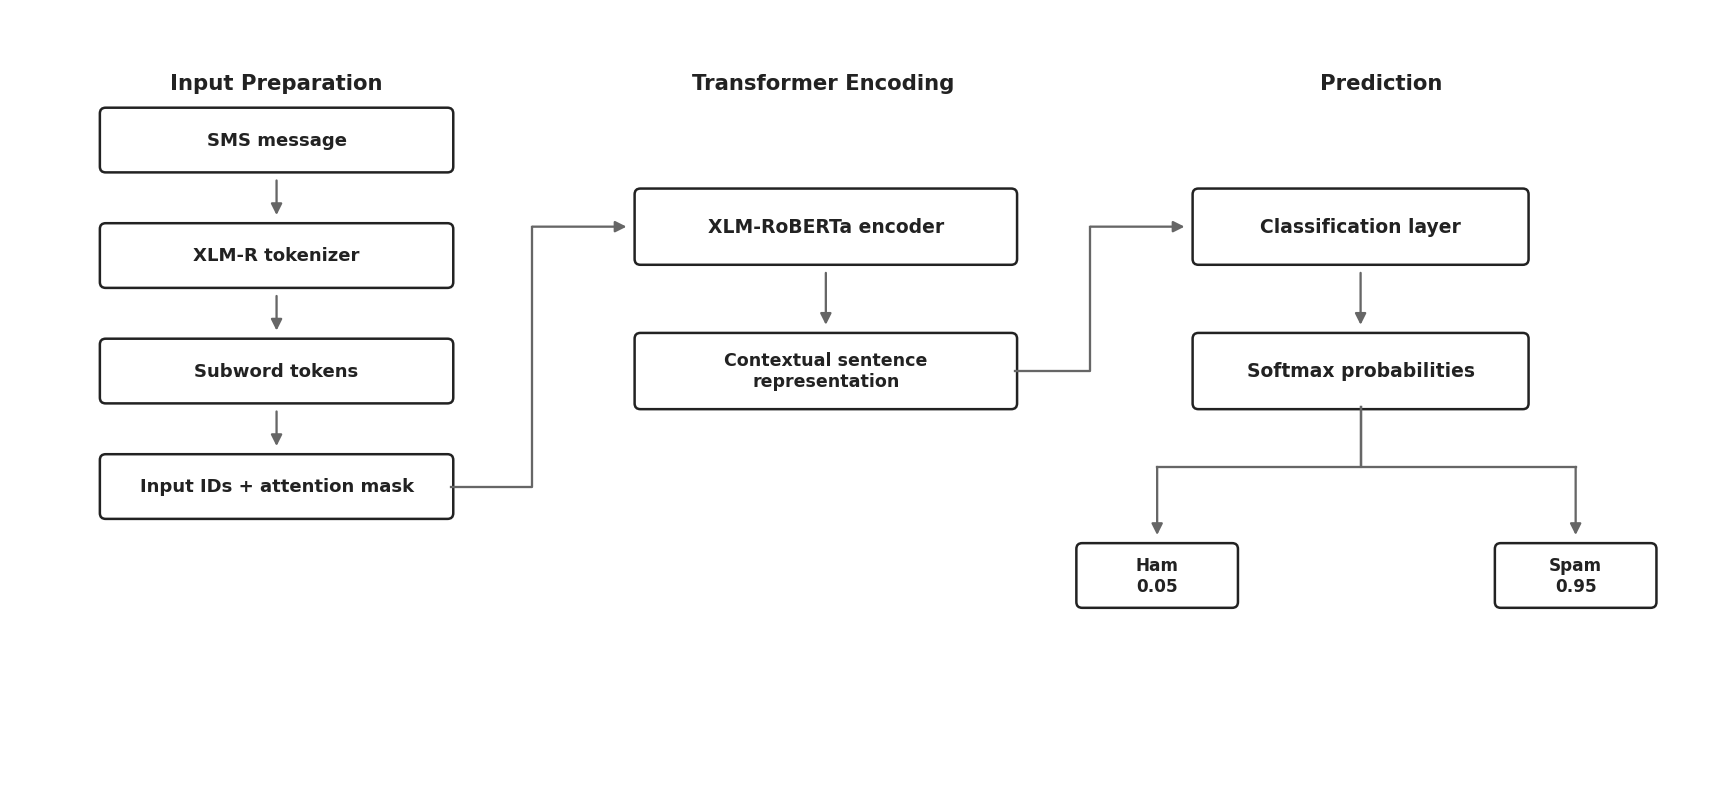

Saved to: D:\Project\Leeds\Msc Project\figure\figure_2_3_xlmr_workflow.png


In [11]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# Save path
project_dir = Path(r"D:\Project\Leeds\Msc Project")
figure_dir = project_dir / "figure"
figure_dir.mkdir(parents=True, exist_ok=True)

output_path = figure_dir / "figure_2_3_xlmr_workflow.png"

black = "#222222"
grey = "#666666"
white = "#ffffff"

def add_box(ax, x, y, w, h, text, fontsize=8.8, weight="normal", lw=1.2):
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.02,rounding_size=0.05",
        linewidth=lw,
        edgecolor=black,
        facecolor=white,
    )
    ax.add_patch(box)
    ax.text(
        x + w / 2, y + h / 2, text,
        ha="center", va="center",
        fontsize=fontsize, fontweight=weight, color=black,
    )
    return box

def arrow(ax, start, end, lw=1.1):
    connector = FancyArrowPatch(
        start, end,
        arrowstyle="-|>",
        mutation_scale=11,
        linewidth=lw,
        color=grey,
        shrinkA=5,
        shrinkB=5,
    )
    ax.add_patch(connector)

def elbow_arrow(ax, points, lw=1.1):
    if len(points) > 2:
        ax.plot(
            [p[0] for p in points[:-1]],
            [p[1] for p in points[:-1]],
            color=grey,
            linewidth=lw,
        )
    connector = FancyArrowPatch(
        points[-2], points[-1],
        arrowstyle="-|>",
        mutation_scale=11,
        linewidth=lw,
        color=grey,
        shrinkA=0,
        shrinkB=5,
    )
    ax.add_patch(connector)

# Figure setup
fig, ax = plt.subplots(figsize=(14.5, 6.7), dpi=150)
ax.set_xlim(0, 14.5)
ax.set_ylim(0, 6.7)
ax.axis("off")

# Section labels
ax.text(2.25, 6.10, "Input Preparation",
        ha="center", va="center", fontsize=10.2, fontweight="bold", color=black)
ax.text(6.95, 6.10, "Transformer Encoding",
        ha="center", va="center", fontsize=10.2, fontweight="bold", color=black)
ax.text(11.75, 6.10, "Prediction",
        ha="center", va="center", fontsize=10.2, fontweight="bold", color=black)

# Input preparation column
x1 = 0.75
w1 = 3.00
h = 0.52
input_steps = [
    ("SMS message", 5.35),
    ("XLM-R tokenizer", 4.35),
    ("Subword tokens", 3.35),
    ("Input IDs + attention mask", 2.35),
]

for label, y in input_steps:
    add_box(ax, x1, y, w1, h, label, fontsize=8.7, weight="bold")

for i in range(len(input_steps) - 1):
    y1 = input_steps[i][1]
    y2 = input_steps[i + 1][1]
    arrow(ax, (x1 + w1 / 2, y1), (x1 + w1 / 2, y2 + h))

# Transformer encoding column
x2 = 5.35
w2 = 3.25
add_box(ax, x2, 4.55, w2, 0.62,
        "XLM-RoBERTa encoder", fontsize=9.0, weight="bold")
add_box(ax, x2, 3.30, w2, 0.62,
        "Contextual sentence\nrepresentation", fontsize=8.4, weight="bold")
arrow(ax, (x2 + w2 / 2, 4.55), (x2 + w2 / 2, 3.92))

# Connection from prepared input to encoder.
elbow_arrow(ax, [
    (x1 + w1, 2.61),
    (4.45, 2.61),
    (4.45, 4.86),
    (x2, 4.86),
])

# Prediction column
x3 = 10.15
w3 = 2.85
add_box(ax, x3, 4.55, w3, 0.62,
        "Classification layer", fontsize=9.0, weight="bold")
add_box(ax, x3, 3.30, w3, 0.62,
        "Softmax probabilities", fontsize=9.0, weight="bold")
add_box(ax, 9.15, 1.58, 1.35, 0.52,
        "Ham\n0.05", fontsize=8.1, weight="bold")
add_box(ax, 12.75, 1.58, 1.35, 0.52,
        "Spam\n0.95", fontsize=8.1, weight="bold")

elbow_arrow(ax, [
    (x2 + w2, 3.61),
    (9.25, 3.61),
    (9.25, 4.86),
    (x3, 4.86),
])
arrow(ax, (x3 + w3 / 2, 4.55), (x3 + w3 / 2, 3.92))
elbow_arrow(ax, [
    (x3 + w3 / 2, 3.30),
    (x3 + w3 / 2, 2.78),
    (9.825, 2.78),
    (9.825, 2.10),
])
elbow_arrow(ax, [
    (x3 + w3 / 2, 3.30),
    (x3 + w3 / 2, 2.78),
    (13.425, 2.78),
    (13.425, 2.10),
])


plt.savefig(output_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Saved to: {output_path}")


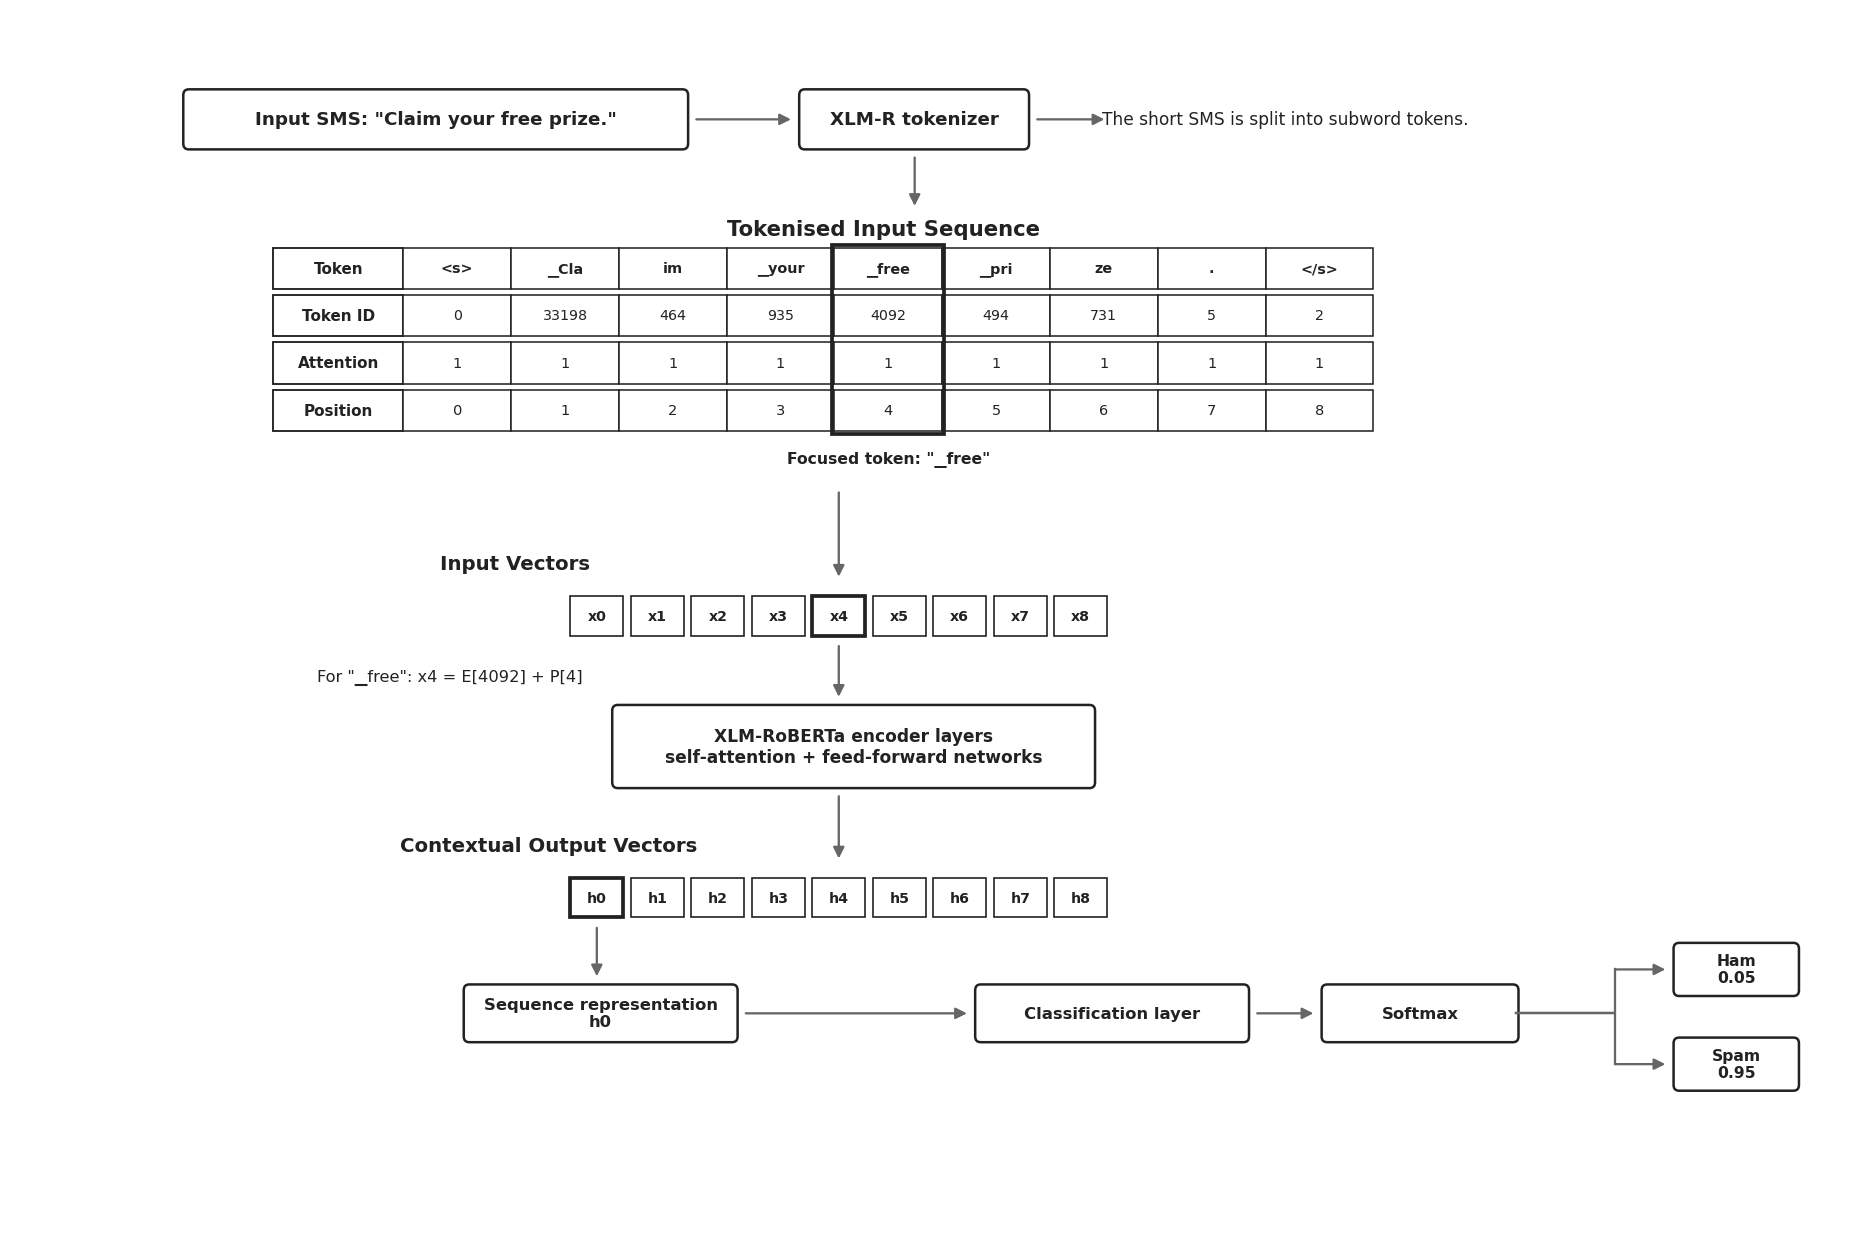

Saved to: D:\Project\Leeds\Msc Project\figure\figure_2_4_xlmr_internal_processing.png


In [12]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle

# Save path
project_dir = Path(r"D:\Project\Leeds\Msc Project")
figure_dir = project_dir / "figure"
figure_dir.mkdir(parents=True, exist_ok=True)

output_path = figure_dir / "figure_2_4_xlmr_internal_processing.png"

# Actual local XLM-RoBERTa tokenizer output for:
# "Claim your free prize."
tokens = ["<s>", "▁Cla", "im", "▁your", "▁free", "▁pri", "ze", ".", "</s>"]
token_ids = [0, 33198, 464, 935, 4092, 494, 731, 5, 2]
attention_mask = [1] * len(tokens)
position_ids = list(range(len(tokens)))

black = "#222222"
grey = "#666666"
white = "#ffffff"

def add_box(ax, x, y, w, h, text, fontsize=8.7, weight="normal", lw=1.2):
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.02,rounding_size=0.05",
        linewidth=lw,
        edgecolor=black,
        facecolor=white,
    )
    ax.add_patch(box)
    ax.text(
        x + w / 2, y + h / 2, text,
        ha="center", va="center",
        fontsize=fontsize, fontweight=weight, color=black,
    )
    return box

def add_cell(ax, x, y, w, h, text, fontsize=7.0, weight="normal", lw=0.8):
    rect = Rectangle((x, y), w, h, linewidth=lw, edgecolor=black, facecolor=white)
    ax.add_patch(rect)
    ax.text(
        x + w / 2, y + h / 2, str(text),
        ha="center", va="center",
        fontsize=fontsize, fontweight=weight, color=black,
    )
    return rect

def arrow(ax, start, end, lw=1.1):
    connector = FancyArrowPatch(
        start, end,
        arrowstyle="-|>",
        mutation_scale=11,
        linewidth=lw,
        color=grey,
        shrinkA=5,
        shrinkB=5,
    )
    ax.add_patch(connector)

def elbow_arrow(ax, points, lw=1.1):
    if len(points) > 2:
        ax.plot(
            [p[0] for p in points[:-1]],
            [p[1] for p in points[:-1]],
            color=grey,
            linewidth=lw,
        )
    connector = FancyArrowPatch(
        points[-2], points[-1],
        arrowstyle="-|>",
        mutation_scale=11,
        linewidth=lw,
        color=grey,
        shrinkA=0,
        shrinkB=5,
    )
    ax.add_patch(connector)

# Figure setup
fig, ax = plt.subplots(figsize=(15.8, 10.5), dpi=150)
ax.set_xlim(0, 16.7)
ax.set_ylim(0, 10.5)
ax.axis("off")


add_box(ax, 1.55, 9.35, 4.55, 0.48,
        'Input SMS: "Claim your free prize."', fontsize=8.8, weight="bold")
add_box(ax, 7.15, 9.35, 2.05, 0.48,
        "XLM-R tokenizer", fontsize=8.8, weight="bold")
arrow(ax, (6.10, 9.59), (7.15, 9.59))
ax.text(11.55, 9.59, "The short SMS is split into subword tokens.",
        ha="center", va="center", fontsize=8.2, color=black)
arrow(ax, (9.20, 9.59), (10.00, 9.59))

# Token table
table_x = 2.35
table_y = 8.12
label_w = 1.18
cell_w = 0.98
cell_h = 0.36
row_gap = 0.05

ax.text(7.9, 8.64, "Tokenised Input Sequence",
        ha="center", va="center", fontsize=10.2, fontweight="bold", color=black)
arrow(ax, (8.18, 9.35), (8.18, 8.75))

rows = [
    ("Token", tokens, 6.9),
    ("Token ID", token_ids, 6.8),
    ("Attention", attention_mask, 7.0),
    ("Position", position_ids, 7.0),
]

for row_index, (label, values, fs) in enumerate(rows):
    y = table_y - row_index * (cell_h + row_gap)
    add_cell(ax, table_x, y, label_w, cell_h, label, fontsize=7.3, weight="bold", lw=0.9)
    for col, value in enumerate(values):
        x = table_x + label_w + col * cell_w
        add_cell(
            ax, x, y, cell_w, cell_h, value,
            fontsize=fs,
            weight="bold" if row_index == 0 else "normal",
            lw=0.75,
        )

free_index = tokens.index("▁free")
free_x = table_x + label_w + free_index * cell_w
highlight_y = table_y - 3 * (cell_h + row_gap)
highlight_h = 4 * cell_h + 3 * row_gap
ax.add_patch(Rectangle(
    (free_x - 0.02, highlight_y - 0.02),
    cell_w + 0.04, highlight_h + 0.04,
    linewidth=1.8, edgecolor=black, facecolor="none",
))
ax.text(free_x + cell_w / 2, highlight_y - 0.23,
        'Focused token: "▁free"',
        ha="center", va="center", fontsize=7.5, fontweight="bold", color=black)


seq_x = 5.05
seq_y = 5.12
vec_w = 0.48
vec_h = 0.34
vec_gap = 0.07
row_mid_x = seq_x + (len(tokens) * vec_w + (len(tokens) - 1) * vec_gap) / 2

ax.text(4.55, seq_y + 0.62, "Input Vectors",
        ha="center", va="center", fontsize=9.5, fontweight="bold", color=black)
arrow(ax, (7.49, 6.45), (7.49, seq_y + vec_h + 0.08))

for i in range(len(tokens)):
    lw = 1.8 if i == free_index else 0.8
    add_cell(ax, seq_x + i * (vec_w + vec_gap), seq_y,
             vec_w, vec_h, f"x{i}", fontsize=6.8, weight="bold", lw=lw)

ax.text(3.95, seq_y - 0.36,
        'For "▁free": x4 = E[4092] + P[4]',
        ha="center", va="center", fontsize=7.8, color=black)

# Encoder
encoder_x = 5.45
encoder_y = 3.82
encoder_w = 4.35
encoder_h = 0.68
add_box(ax, encoder_x, encoder_y, encoder_w, encoder_h,
        "XLM-RoBERTa encoder layers\nself-attention + feed-forward networks",
        fontsize=8.2, weight="bold")
arrow(ax, (row_mid_x, seq_y), (row_mid_x, encoder_y + encoder_h))

# Contextual output vectors
out_y = 2.68
ax.text(4.85, out_y + 0.62, "Contextual Output Vectors",
        ha="center", va="center", fontsize=9.5, fontweight="bold", color=black)
arrow(ax, (row_mid_x, encoder_y), (row_mid_x, out_y + vec_h + 0.08))

for i in range(len(tokens)):
    lw = 1.8 if i == 0 else 0.8
    add_cell(ax, seq_x + i * (vec_w + vec_gap), out_y,
             vec_w, vec_h, f"h{i}", fontsize=6.8, weight="bold", lw=lw)


add_box(ax, 4.10, 1.62, 2.45, 0.46,
        "Sequence representation\nh0", fontsize=7.9, weight="bold")
add_box(ax, 8.75, 1.62, 2.45, 0.46,
        "Classification layer", fontsize=7.9, weight="bold")
add_box(ax, 11.90, 1.62, 1.75, 0.46,
        "Softmax", fontsize=7.9, weight="bold")
add_box(ax, 15.10, 2.02, 1.10, 0.42,
        "Ham\n0.05", fontsize=7.5, weight="bold")
add_box(ax, 15.10, 1.20, 1.10, 0.42,
        "Spam\n0.95", fontsize=7.5, weight="bold")

arrow(ax, (seq_x + vec_w / 2, out_y), (seq_x + vec_w / 2, 2.08))
arrow(ax, (6.55, 1.85), (8.75, 1.85))
arrow(ax, (11.20, 1.85), (11.90, 1.85))
elbow_arrow(ax, [(13.65, 1.85), (14.55, 1.85), (14.55, 2.23), (15.10, 2.23)])
elbow_arrow(ax, [(13.65, 1.85), (14.55, 1.85), (14.55, 1.41), (15.10, 1.41)])


plt.savefig(output_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Saved to: {output_path}")


In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Save path
project_dir = Path(r"D:\Project\Leeds\Msc Project")
figure_dir = project_dir / "figure"
figure_dir.mkdir(parents=True, exist_ok=True)
output_path = figure_dir / "figure_2_5_confusion_matrix.png"

black = "#222222"
grey = "#555555"
white = "#ffffff"

fig, ax = plt.subplots(figsize=(8.2, 6.2), dpi=150)
ax.set_xlim(0, 8.2)
ax.set_ylim(0, 6.2)
ax.axis("off")

# Matrix geometry
x0 = 2.35
y0 = 1.15
cell_w = 2.25
cell_h = 1.55

# Axis titles
ax.text(x0 + cell_w, 5.45, "Predicted label", ha="center", va="center",
        fontsize=14, fontweight="bold", color=black)
ax.text(0.65, y0 + cell_h, "Actual\nlabel", ha="center", va="center",
        fontsize=14, fontweight="bold", color=black)

# Column headers
ax.text(x0 + cell_w * 0.5, 4.65, "Spam", ha="center", va="center",
        fontsize=12.5, fontweight="bold", color=black)
ax.text(x0 + cell_w * 1.5, 4.65, "Ham", ha="center", va="center",
        fontsize=12.5, fontweight="bold", color=black)

# Row headers
ax.text(1.55, y0 + cell_h * 1.5, "Spam", ha="center", va="center",
        fontsize=12.5, fontweight="bold", color=black)
ax.text(1.55, y0 + cell_h * 0.5, "Ham", ha="center", va="center",
        fontsize=12.5, fontweight="bold", color=black)

cells = [
    (0, 1, "TP", "Spam correctly\nclassified as spam"),
    (1, 1, "FN", "Spam incorrectly\nclassified as ham"),
    (0, 0, "FP", "Ham incorrectly\nclassified as spam"),
    (1, 0, "TN", "Ham correctly\nclassified as ham"),
]

for col, row, abbr, desc in cells:
    x = x0 + col * cell_w
    y = y0 + row * cell_h
    ax.add_patch(Rectangle((x, y), cell_w, cell_h,
                           facecolor=white, edgecolor=black, linewidth=1.4))
    ax.text(x + cell_w / 2, y + cell_h * 0.63, abbr,
            ha="center", va="center", fontsize=18, fontweight="bold", color=black)
    ax.text(x + cell_w / 2, y + cell_h * 0.34, desc,
            ha="center", va="center", fontsize=9.2, color=grey, linespacing=1.15)

# Outer border around the four cells
ax.add_patch(Rectangle((x0, y0), cell_w * 2, cell_h * 2,
                       facecolor="none", edgecolor=black, linewidth=2.0))

plt.savefig(output_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Saved to: {output_path}")
